In [1]:
import pandas as pd
csv_path = 'c:/data/test/insurance_regression.csv'
data = pd.read_csv(csv_path)
print(data.head())

   age  years  accidents  premium
0   20      1          2      185
1   22      2          1      170
2   24      1          0      155
3   26      3          0      145
4   28      4          1      160


In [2]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        20 non-null     int64
 1   years      20 non-null     int64
 2   accidents  20 non-null     int64
 3   premium    20 non-null     int64
dtypes: int64(4)
memory usage: 772.0 bytes
None


In [3]:
X = data[['age','years','accidents']]
y = data['premium']
print(X.head())
print(y.head())

   age  years  accidents
0   20      1          2
1   22      2          1
2   24      1          0
3   26      3          0
4   28      4          1
0    185
1    170
2    155
3    145
4    160
Name: premium, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 7)
print(X_train.shape, X_test.shape)

(16, 3) (4, 3)


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1)
])
model.compile(
    loss='mse',
    optimizer='adam',
    metrics=['mae']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

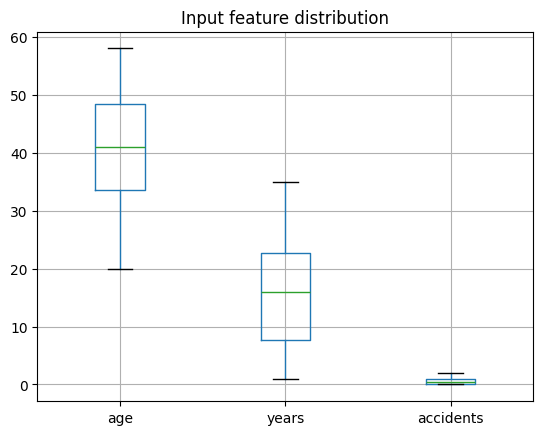

In [6]:
import matplotlib.pyplot as plt
pd.DataFrame(X_train).boxplot()
plt.title('Input feature distribution')
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)
X_train_scaled=pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X_test.columns)

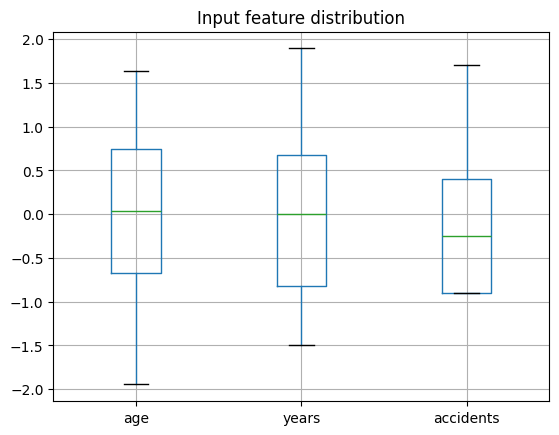

In [8]:
import matplotlib.pyplot as plt

pd.DataFrame(X_train_scaled).boxplot()
plt.title('Input feature distribution')
plt.show()

In [9]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=50
)
hist = model.fit(
    X_train_scaled, y_train,
    epochs=500,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step - loss: 16520.8613 - mae: 126.4337 - val_loss: 19093.3691 - val_mae: 136.4199
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 16517.1562 - mae: 126.4195 - val_loss: 19090.7891 - val_mae: 136.4101
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 16513.4355 - mae: 126.4052 - val_loss: 19088.2012 - val_mae: 136.4002
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 16509.6797 - mae: 126.3910 - val_loss: 19085.5938 - val_mae: 136.3903
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 16505.9531 - mae: 126.3770 - val_loss: 19083.4102 - val_mae: 136.3817
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 16502.2168 - mae: 126.3629 - val_loss: 19081.3555 - val_mae: 136.3736
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 16498.4766 - mae: 126.3489 - val_loss: 19079.3008 - val_mae: 136.3654
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 16494.7344 - mae: 126.3348 - val_loss: 19077.

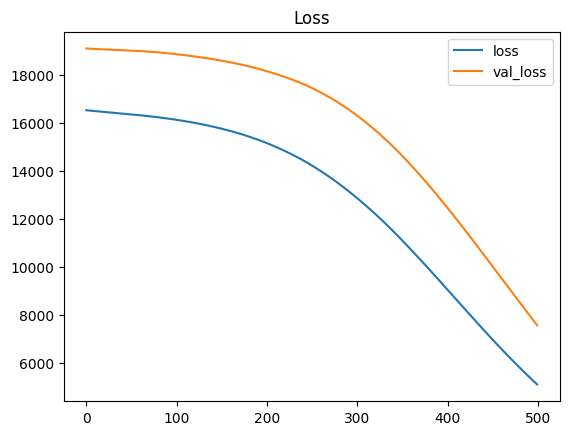

In [10]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.title('Loss')
plt.show()

In [11]:
train_scores = model.evaluate(X_train_scaled, y_train)
test_scores = model.evaluate(X_test_scaled, y_test)
print('Train scores:', train_scores)
print('Test scores:', test_scores)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 5687.9609 - mae: 69.9806
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 5971.1865 - mae: 73.0546
Train scores: [5687.9609375, 69.98057556152344]
Test scores: [5971.1865234375, 73.05458068847656]


In [12]:
from sklearn.metrics import r2_score
pred = model.predict(X_test_scaled)
print('R2 score:', r2_score(y_test, pred))
print('실제값:', list(y_test[:5]))
print('예측값:', pred[:5].reshape(-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
R2 score: -6.53759241104126
실제값: [170, 95, 155, 135]
예측값: [63.174137 59.06699  77.7468   62.79375 ]
